# Calibration polynomial arithmetic: linear in order

- Old: `(n_pix, k, k)` Gram reduction, LU solve, separate slogdet.
- New: Chebyshev moments $N_{mn} = \tfrac12 (M_{m+n} + M_{|m-n|})$, one Cholesky for $\hat a$ and $\ln|N|$.
- Timing: `scripts/benchmark_calibration_order.py`, both variants in one process on one GPU.
- Refit: `poly10` M12_98104 with the new code against `results/calibration-order/poly10` (old code, same seed).

In [1]:
import json
import os
import sys
from pathlib import Path

os.environ.setdefault("JAX_PLATFORMS", "cpu")
import corner
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path(os.environ.get("CERIDWEN_PROJECT_ROOT", Path.cwd()))
while not (PROJECT_ROOT / "scripts" / "per_galaxy_diagnostics.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "scripts"))
import per_galaxy_diagnostics as pgd  # noqa: E402
from build_dr2_quiescent_summary import FEH_OFFSET, formation_times  # noqa: E402
from spectral_figures import (  # noqa: E402
    mark_absorption_features,
    mark_rest_wavelength_axis,
    set_plain_log_ticks,
    spectral_tight_layout,
)

TEST_ROOT = os.environ.get("CERIDWEN_SPEEDUP_RESULTS")  # scratch tree for test runs; unset in the committed execution
RESULTS = Path(TEST_ROOT) if TEST_ROOT else PROJECT_ROOT / "results/calibration-speedup"
TARGET = "M12_98104"
FIT_DIRS = {"old": PROJECT_ROOT / "results/calibration-order/poly10" / f"98104-{TARGET}",
            "new": RESULTS / "poly10" / f"98104-{TARGET}"}
COLOURS = {"old": "k", "new": "tab:red"}
LABELS = {"logmass": r"$\log_{10}(M_\star/M_\odot)$", "Z": r"$[\mathrm{Fe}/\mathrm{H}]$", "afe": r"$[\alpha/\mathrm{Fe}]$",
          "tau_dust": r"$\tau_{\mathrm{dust}}$", "dust_index": r"$\delta_{\rm dust}$", "age": r"$t_{\mathrm{MW}}$ [Gyr]"}
pd.set_option("display.width", 250); pd.set_option("display.max_columns", 60); pd.set_option("display.precision", 3)

## Timing by order and variant

- `timing-gpu.json`: median wall time of `jit(vmap(loglike))` over 20 calls, per particle count.
- Speed-up = old / new at the same order and particle count.

In [2]:
timing = json.loads((RESULTS / "timing-gpu.json").read_text())
rows = pd.DataFrame(timing["rows"])
print(timing["device_kind"], "| jax", timing["jax"], "| target", timing["target"], "| pixels", timing["spectral_pixels"])
us = rows.pivot_table(index=["particles", "order"], columns="variant", values="us_per_call")[["old", "new"]]
us["speedup"] = us["old"] / us["new"]
us.to_csv(RESULTS / "timing.csv")
display(us)
# Same-process check: both variants return the same log-likelihood sum.
agree = rows.pivot_table(index=["particles", "order"], columns="variant", values="loglike_sum")
display((agree["old"] - agree["new"]).abs().max() / agree["new"].abs().max())

NVIDIA GeForce RTX 5060 | jax 0.10.2 | target M1_210210 | pixels 3523


variant              old     new  speedup
particles order                          
100       0          NaN  12.546      NaN
          3       16.693  16.408    1.017
          5       18.470  16.726    1.104
          10      35.904  17.080    2.102
          24     131.356  21.382    6.143
500       0          NaN   5.875      NaN
          3        8.409   7.576    1.110
          5       10.470   7.706    1.359
          10      19.475   8.304    2.345
          24      76.167   9.943    7.661

np.float64(0.0)

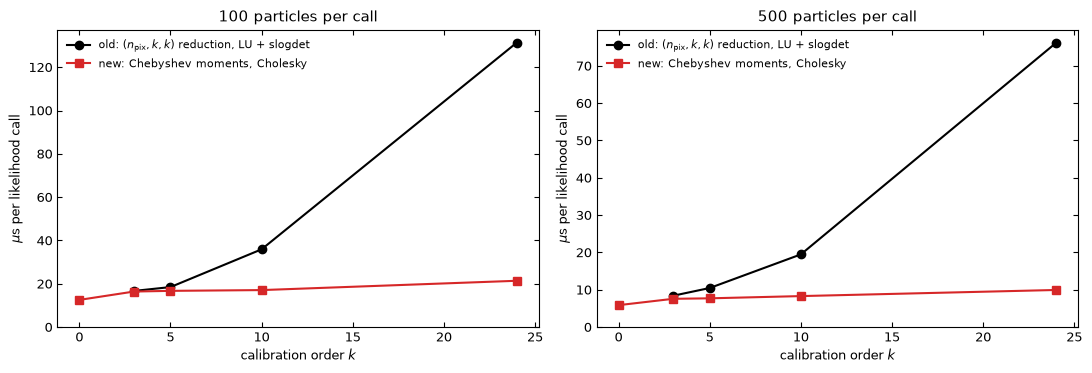

In [3]:
counts = us.index.get_level_values("particles").unique()
fig, axes = plt.subplots(1, len(counts), figsize=(5.5 * len(counts), 3.8), squeeze=False)
for ax, (count, sub) in zip(axes.ravel(), us.groupby(level="particles")):
    orders = sub.index.get_level_values("order")
    ax.plot(orders, sub["old"], "o-", color="k", label="old: $(n_{\\rm pix}, k, k)$ reduction, LU + slogdet")
    ax.plot(orders, sub["new"], "s-", color="tab:red", label="new: Chebyshev moments, Cholesky")
    ax.set(xlabel="calibration order $k$", ylabel=r"$\mu$s per likelihood call", title=f"{count} particles per call", ylim=(0, None))
    ax.legend(frameon=False, fontsize=8)
fig.tight_layout(); fig.savefig(RESULTS / "timing-by-order.png", dpi=130); plt.show()

## Refit at order 10: old and new code

- Same target, seed rule and NSS settings; different Vast boot.
- Wall time is not a same-boot comparison; lnZ and parameters are.

In [4]:
def _text(v):
    return v.decode() if isinstance(v, bytes) else str(v)


def load_fit(folder):
    out = {"folder": folder}
    with h5py.File(folder / "ceridwen_derived_outputs.h5", "r") as d:
        out["attrs"] = dict(d.attrs)
        names = [_text(v) for v in d["summary/parameter"][:]]
        out["summary"] = pd.DataFrame({"q16": d["summary/q16"][:], "q50": d["summary/q50"][:], "q84": d["summary/q84"][:]}, index=names)
        out["diag"] = dict(d["diagnostics"].attrs)
        for grp in ("spectrum", "photometry", "sfh", "calibration"):
            out[grp] = {k: d[grp][k][:] for k in d[grp]}
        out["calibration"]["attrs"] = dict(d["calibration"].attrs)
    with h5py.File(folder / "ceridwen_result.h5", "r") as r:
        out["n_calls"] = int(r["samples"].attrs["n_likelihood_calls"])
        out["wall_s"] = float(r["samples"].attrs["wall_time_s"])
    out["galaxy"] = pgd.load_galaxy(folder)
    return out


fits = {k: load_fit(v) for k, v in FIT_DIRS.items()}


def summary_row(fit):
    s, d = fit["summary"], fit["diag"]
    g = fit["galaxy"]; w = pgd.posterior_weights(g)
    _, t50, _ = formation_times(fit["sfh"]["lookback_time_gyr"], fit["sfh"]["mass_fraction_draws"])
    row = dict(order=int(fit["calibration"]["attrs"]["order"]), seed=g.seed, lnZ=float(d["log_evidence"]), lnZ_err=float(d["log_evidence_err"]),
               phot_chi2=float(d["photometry_chi2"]), spec_chi2_stored=float(d["spectrum_chi2"]), ess=float(d["posterior_weight_ess"]),
               calls=fit["n_calls"], wall_s=fit["wall_s"], us_per_call=1e6 * fit["wall_s"] / fit["n_calls"])
    for name, key in [("logmass", "logmass"), ("Z", "Z"), ("afe", "afe"), ("tau_dust", "diffuse_tau_kc"),
                      ("age", "mass-weighted age [Gyr]"), ("f_calib", "calibration floor [%]")]:
        row[f"{name}_q50"], row[f"{name}_hw"] = s.loc[key, "q50"], 0.5 * (s.loc[key, "q84"] - s.loc[key, "q16"])
    q16, q50, q84 = (pgd.weighted_quantile(np.ravel(g.samples["diffuse_dust_index"]), w, q) for q in (0.16, 0.5, 0.84))
    row["dust_index_q50"], row["dust_index_hw"] = q50, 0.5 * (q84 - q16)
    q16, q50, q84 = np.percentile(t50, [16, 50, 84])
    row["t50_q50"], row["t50_hw"] = q50, 0.5 * (q84 - q16)
    return row


table = pd.DataFrame({k: summary_row(v) for k, v in fits.items()}).T
table.loc["new - old"] = table.loc["new"] - table.loc["old"]
table.to_csv(RESULTS / "refit.csv")
display(table)

,order,seed,lnZ,lnZ_err,phot_chi2,spec_chi2_stored,ess,calls,wall_s,us_per_call,logmass_q50,logmass_hw,Z_q50,Z_hw,afe_q50,afe_hw,tau_dust_q50,tau_dust_hw,age_q50,age_hw,f_calib_q50,f_calib_hw,dust_index_q50,dust_index_hw,t50_q50,t50_hw
old,10.0,2.026e+07,249687.645,0.271,14.505,5842.266,3537.19,5.348e+06,723.498,135.289,1.116e+01,0.041,-2.115,9.081e-02,5.580e-02,4.708e-02,1.923e-01,8.641e-03,3.907,0.464,9.985,0.020,-0.816,0.171,4.065,0.547
new,10.0,2.026e+07,249688.019,0.283,14.407,5843.449,3604.35,5.316e+06,392.967,73.928,1.116e+01,0.034,-2.125,9.067e-02,5.539e-02,4.776e-02,1.918e-01,9.010e-03,3.875,0.396,9.983,0.025,-0.814,0.167,4.009,0.457
new - old,0.0,0.000e+00,0.374,0.012,-0.097,1.183,67.16,-3.228e+04,-330.531,-61.361,-7.762e-04,-0.006,-0.010,-1.400e-04,-4.119e-04,6.824e-04,-4.681e-04,3.686e-04,-0.032,-0.068,-0.001,0.005,0.002,-0.004,-0.056,-0.090


## Fit, SFH and corner

- Spectrum and photometry medians for both codes; SFH median with 16-84 band; weighted dead points, 1σ contours.

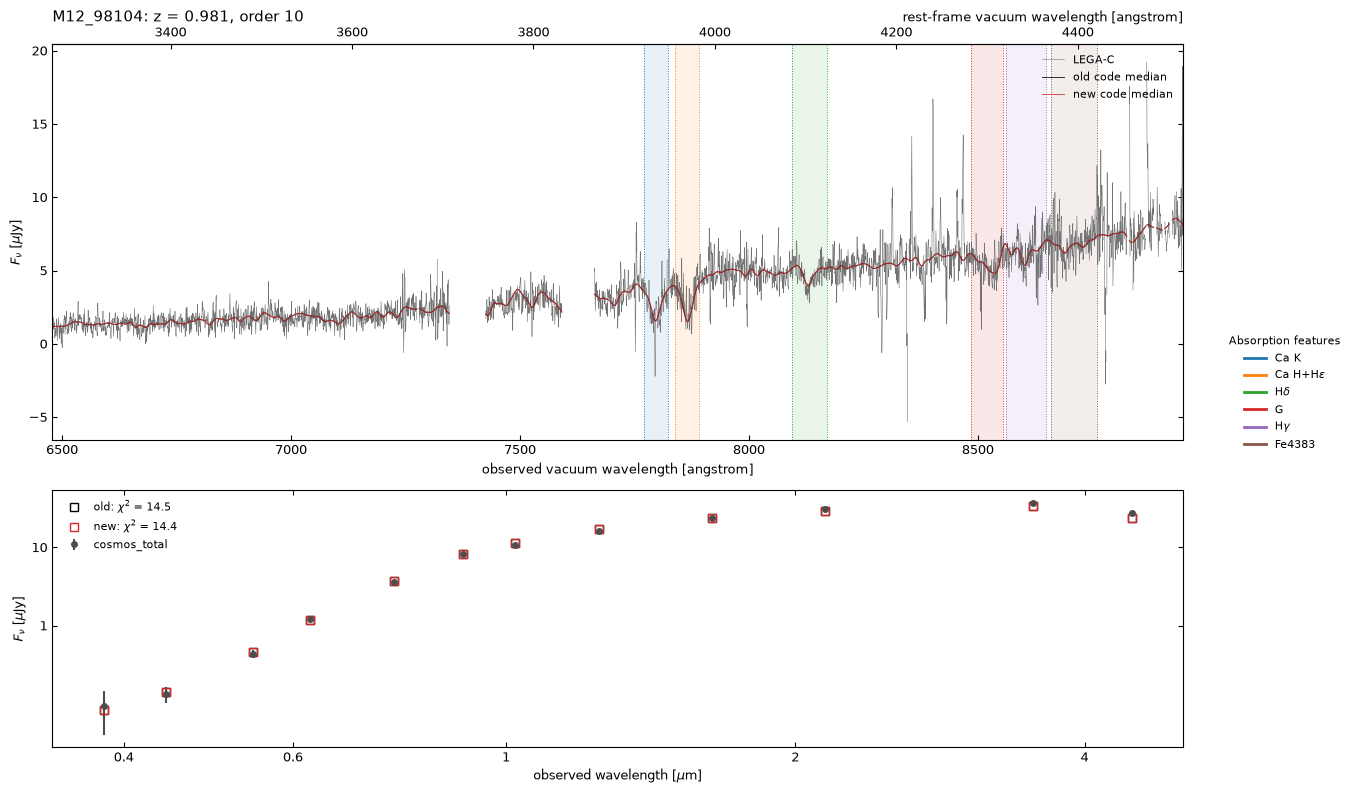

In [5]:
ref = fits["old"]; s = ref["spectrum"]; wave = s["wavelength"]; rmask = s["mask"].astype(bool)
fig, axes = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={"height_ratios": [2, 1.3]})
UJY_PER_CGS = 1e29        # spectrum stored in erg/s/cm^2/Hz
UJY_PER_MAGGIE = 3631e6   # photometry stored in maggies
axes[0].plot(wave, np.where(rmask, s["observed"] * UJY_PER_CGS, np.nan), color="0.45", lw=0.4, label="LEGA-C")
p = ref["photometry"]; pm = p["mask"].astype(bool); lam = p["wavelength"] / 1e4
axes[1].errorbar(lam[pm], p["observed"][pm] * UJY_PER_MAGGIE, yerr=p["uncertainty"][pm] * UJY_PER_MAGGIE, fmt="o", color="0.3", ms=4, label="cosmos_total")
for k, fit in fits.items():
    axes[0].plot(wave, np.where(rmask, fit["spectrum"]["posterior_q50"] * UJY_PER_CGS, np.nan), color=COLOURS[k], lw=0.7, alpha=0.8, label=f"{k} code median")
    q = fit["photometry"]
    axes[1].plot(lam[pm], q["posterior_q50"][pm] * UJY_PER_MAGGIE, "s", mfc="none", color=COLOURS[k], ms=6, label=rf"{k}: $\chi^2$ = {np.sum(q['pull'][pm] ** 2):.1f}")
axes[0].set_xlim(wave[rmask].min(), wave[rmask].max())
axes[0].set_ylabel(r"$F_\nu$ [$\mu$Jy]")
axes[0].legend(frameon=False, fontsize=8, loc="upper right")
axes[1].set(xscale="log", yscale="log", xlabel=r"observed wavelength [$\mu$m]", ylabel=r"$F_\nu$ [$\mu$Jy]")
set_plain_log_ticks(axes[1].xaxis, (0.4, 0.6, 1, 2, 4))
set_plain_log_ticks(axes[1].yaxis, (1, 10, 100))
axes[1].legend(frameon=False, fontsize=8)
mark_absorption_features(axes[0], ref["attrs"]["redshift"], xlabel="observed vacuum wavelength [angstrom]")
mark_rest_wavelength_axis(axes[0], float(ref["attrs"]["redshift"]), label="rest-frame vacuum wavelength [angstrom]",
                          title=f"{TARGET}: z = {ref['attrs']['redshift']:.3f}, order 10")
spectral_tight_layout(fig)
fig.savefig(RESULTS / f"fit-{TARGET}.png", dpi=150); plt.show()

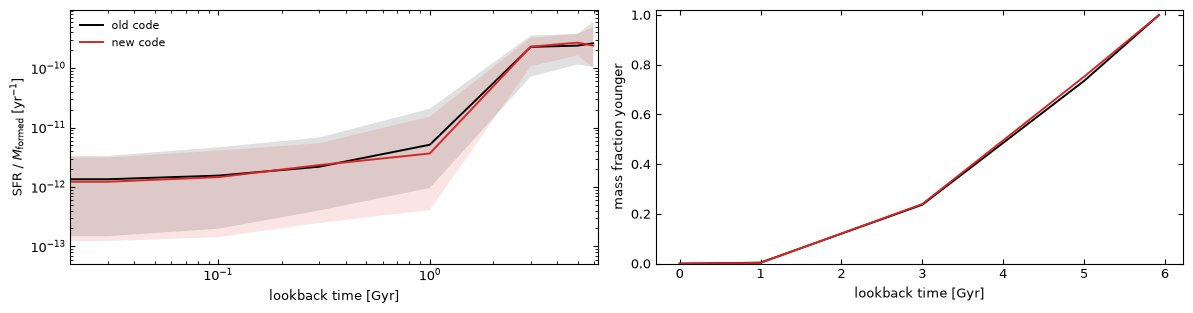

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.2))
for k, fit in fits.items():
    sfh = fit["sfh"]; lb = sfh["lookback_time_gyr"]
    axes[0].plot(lb, sfh["normalized_sfr_q50"], color=COLOURS[k], lw=1.4, label=f"{k} code")
    axes[0].fill_between(lb, sfh["normalized_sfr_q16"], sfh["normalized_sfr_q84"], color=COLOURS[k], alpha=0.12, lw=0)
    younger = np.concatenate([[0.0], np.cumsum(sfh["mass_fraction_q50"])])
    axes[1].plot(lb, younger / younger[-1], color=COLOURS[k], lw=1.4, label=f"{k} code")
axes[0].set(xscale="log", yscale="log", xlabel="lookback time [Gyr]", ylabel=r"SFR / $M_{\rm formed}$ [yr$^{-1}$]", xlim=(0.02, lb[-1] * 1.05))
axes[1].set(xlabel="lookback time [Gyr]", ylabel="mass fraction younger", ylim=(0, 1.02))
axes[0].legend(frameon=False, fontsize=8)
fig.tight_layout(); fig.savefig(RESULTS / f"sfh-{TARGET}.png", dpi=130); plt.show()

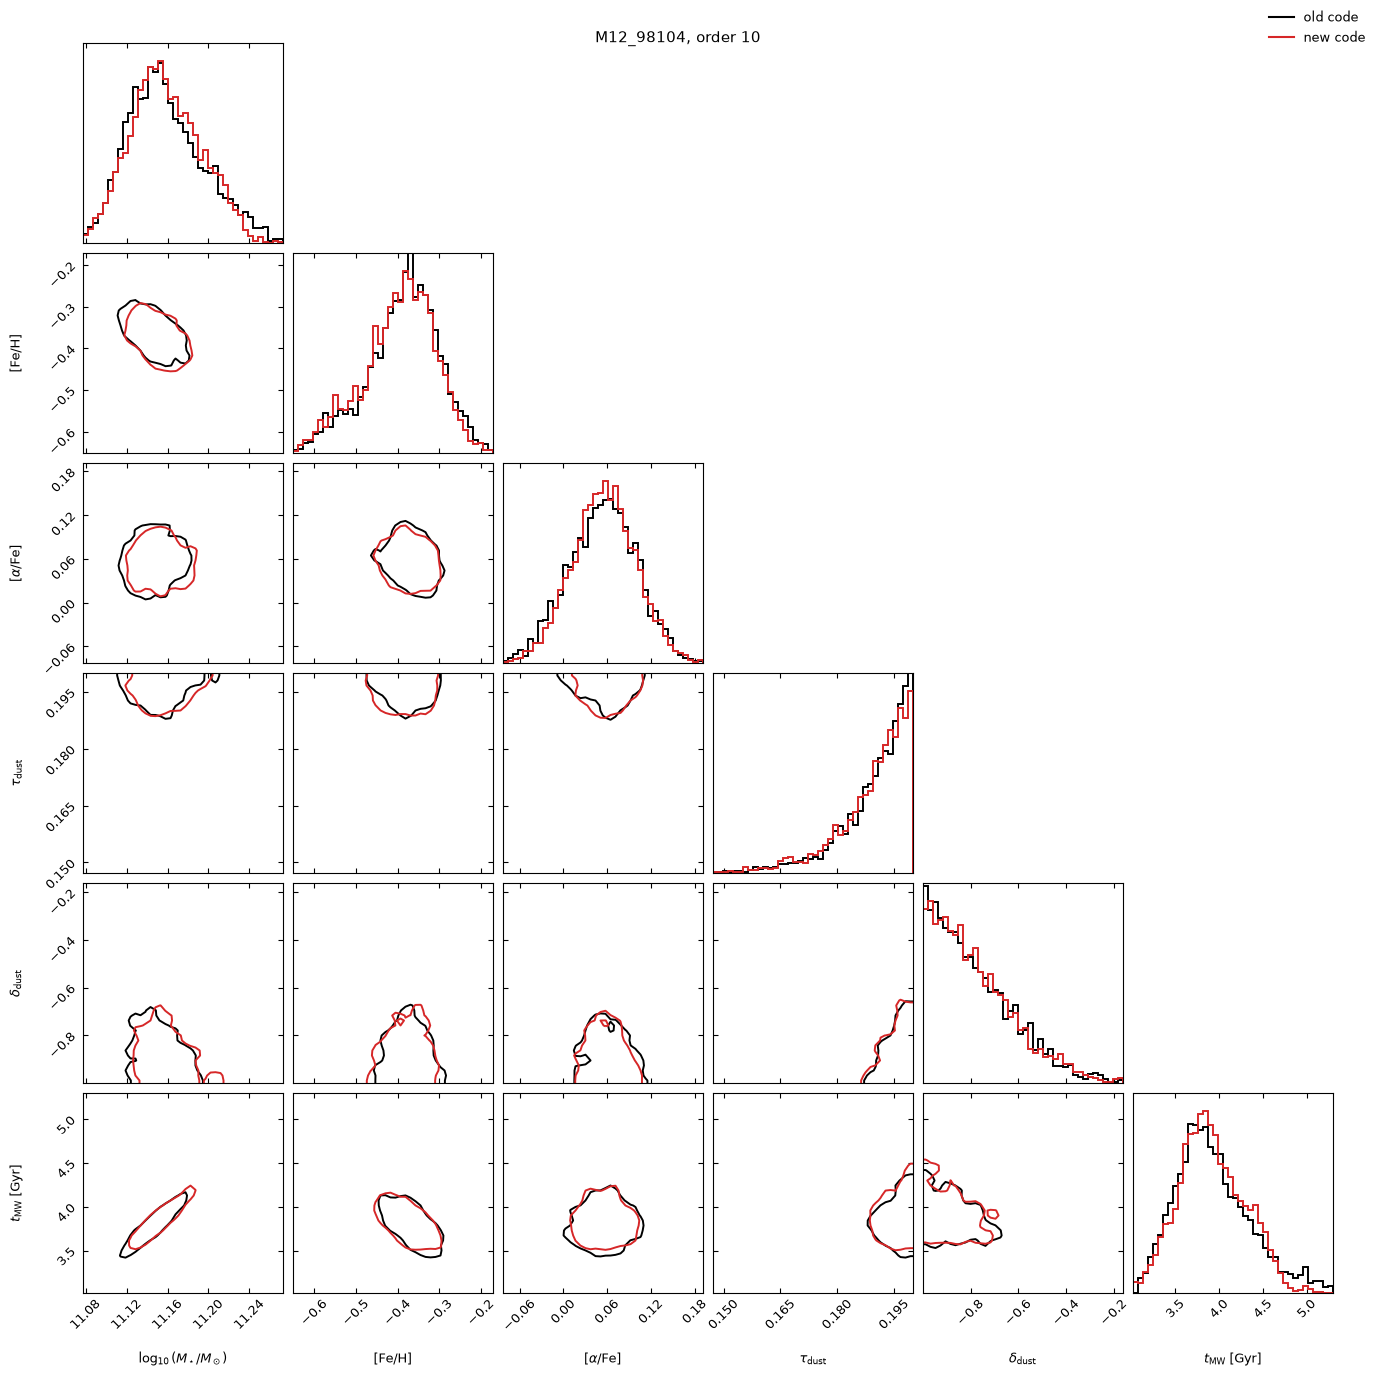

In [7]:
CORNER_PARAMS = ["logmass", "Z", "afe", "tau_dust", "dust_index", "age"]


def mw_age_samples(g):
    r = np.asarray(g.samples["logsfr_ratios"])
    h = 10.0 ** np.concatenate([np.zeros((len(r), 1)), -np.cumsum(r, axis=1)], axis=1)
    edges = g.sfh_edges_gyr
    m = 0.5 * (h[:, :-1] + h[:, 1:]) * np.diff(edges)
    return (m * (0.5 * (edges[:-1] + edges[1:]))).sum(1) / m.sum(1)


def corner_data(g):
    return np.column_stack([g.samples["logmass"], g.samples["Z"] + FEH_OFFSET, g.samples["afe"], g.samples["diffuse_tau_kc"],
                            g.samples["diffuse_dust_index"], mw_age_samples(g)])


data = {k: (corner_data(f["galaxy"]), pgd.posterior_weights(f["galaxy"])) for k, f in fits.items()}
n = len(CORNER_PARAMS)
lo = np.min([[pgd.weighted_quantile(x[:, i], w, 0.002) for i in range(n)] for x, w in data.values()], axis=0)
hi = np.max([[pgd.weighted_quantile(x[:, i], w, 0.998) for i in range(n)] for x, w in data.values()], axis=0)
rng_ = [(a, b) if b > a else (a - 1e-3, a + 1e-3) for a, b in zip(lo, hi)]
fig = None
for k, (x, w) in data.items():
    fig = corner.corner(x, weights=w, labels=[LABELS[p] for p in CORNER_PARAMS], range=rng_, color=COLOURS[k], fig=fig, bins=40, smooth=1.0,
                        plot_datapoints=False, plot_density=False, fill_contours=False, levels=[1 - np.exp(-0.5)],
                        hist_kwargs=dict(density=True, lw=1.4), contour_kwargs=dict(linewidths=1.4))
fig.legend(handles=[plt.Line2D([], [], color=COLOURS[k], label=f"{k} code") for k in fits], loc="upper right", frameon=False, fontsize=9)
fig.suptitle(f"{TARGET}, order 10", y=0.98)
fig.savefig(RESULTS / f"corner-{TARGET}.png", dpi=110); plt.show()